In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/f6f433f3306f.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/7b29e3783919.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/3218a6d8eb2c.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/299086c6d1b5.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/7a6e384a0846.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/3f49f8d100e9.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/6fb656d506b2.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/269b44e628eb.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/810d3779abd9.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/c3cd0200df79.png
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe/f9156aeffc5e.png
/kaggle/in

In [2]:
import torch
import torchvision
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not enabled.")

PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
CUDA        : True
GPU         : Tesla T4
CUDA version: 12.8


In [3]:
import os
import json
import random
import time
import copy
import warnings

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    WeightedRandomSampler
)

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    log_loss,
    brier_score_loss
)

warnings.filterwarnings("ignore")

# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

SEED = 42

NUM_CLASSES = 5
IMAGE_SIZE = 224

EPOCHS = 50
BATCH_SIZE = 16
NUM_WORKERS = 2

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# Optimizer supplied by teammate was not specified.
# Using Adam as the implementation choice.
OPTIMIZER_NAME = "Adam"

# ============================================================
# PATHS
# ============================================================

DATA_ROOT = Path("/kaggle/input/DR_Classification/aptos")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

OUTPUT_DIR = Path("/kaggle/working/mobilenetv2_results")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    OUTPUT_DIR /
    "best_mobilenetv2_aptos.pth"
)

# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

print("Configuration loaded.")

Configuration loaded.


In [4]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [5]:
from pathlib import Path

DATA_ROOT = Path('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos')
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
TEST_DIR = DATA_ROOT / 'test'

In [6]:
print("=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

for path in [
    DATA_ROOT,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:

    print(
        f"{path}:",
        "EXISTS" if path.exists()
        else "MISSING"
    )

print("\nTrain directory:")
print(list(TRAIN_DIR.iterdir()))

print("\nValidation directory:")
print(list(VAL_DIR.iterdir()))

print("\nTest directory:")
print(list(TEST_DIR.iterdir()))

DATASET VERIFICATION
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos: EXISTS
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train: EXISTS
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val: EXISTS
/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/test: EXISTS

Train directory:
[PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train/3_Severe'), PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train/2_Moderate'), PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train/1_Mild'), PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train/0_No_DR'), PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train/4_Proliferative_DR')]

Validation directory:
[PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/3_Severe'), PosixPath('/kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val/2_Moderate'), PosixPath('/kaggle/

In [7]:
# ============================================================
# TRAIN TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomAffine(
        degrees=40,
        translate=(0.20, 0.20),
        shear=0.20,
        scale=(0.80, 1.20)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# VALIDATION / TEST TRANSFORMS
# ============================================================

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created.")

Transforms created.


In [8]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Train: 2802
Val  : 351
Test : 351

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [9]:
def get_distribution(dataset):

    counts = Counter(
        dataset.targets
    )

    return [
        counts.get(i, 0)
        for i in range(NUM_CLASSES)
    ]


train_counts = get_distribution(
    train_dataset
)

val_counts = get_distribution(
    val_dataset
)

test_counts = get_distribution(
    test_dataset
)

distribution_df = pd.DataFrame({

    "Class": CLASS_NAMES,

    "Train": train_counts,

    "Validation": val_counts,

    "Test": test_counts
})

distribution_df

,Class,Train,Validation,Test
0,No DR,1436,180,180
1,Mild,270,34,34
2,Moderate,738,92,92
3,Severe,141,18,18
4,Proliferative DR,217,27,27


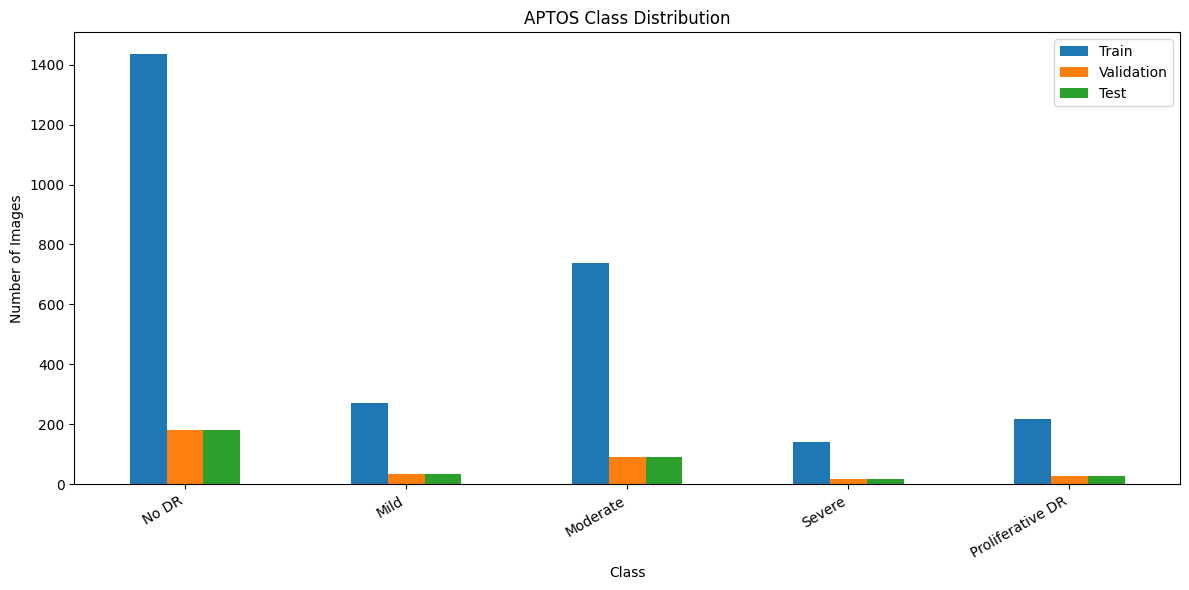

In [10]:
distribution_df.set_index(
    "Class"
).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "APTOS Class Distribution"
)

plt.ylabel("Number of Images")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "class_distribution.png",
    dpi=300
)

plt.show()

In [11]:
# ============================================================
# CALCULATE TRAINING CLASS WEIGHTS
# ============================================================

class_counts = np.bincount(
    train_dataset.targets,
    minlength=NUM_CLASSES
)

class_weights = (
    1.0 /
    class_counts
)

sample_weights = np.array([
    class_weights[label]
    for label in train_dataset.targets
])

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Training class counts:")
print(class_counts)

print("\nClass sampling weights:")
print(class_weights)

Training class counts:
[1436  270  738  141  217]

Class sampling weights:
[0.00069638 0.0037037  0.00135501 0.0070922  0.00460829]


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created.")

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

DataLoaders created.
Training batches: 176
Validation batches: 22
Test batches: 22


In [13]:
# ============================================================
# MOBILE NET V2
# ============================================================

weights = models.MobileNet_V2_Weights.DEFAULT

model = models.mobilenet_v2(
    weights=weights
)

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

print("\nTotal parameters:")

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total     : {total_params:,}"
)

print(
    f"Trainable : {trainable_params:,}"
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 124MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)

Total parameters:
Total     : 2,230,277
Trainable : 2,230,277


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)


In [15]:
def calculate_metrics(
    y_true,
    y_pred,
    y_prob=None
):

    results = {}

    # --------------------------------------------------------
    # Basic classification metrics
    # --------------------------------------------------------

    results["accuracy"] = accuracy_score(
        y_true,
        y_pred
    )

    results["precision_macro"] = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    results["recall_macro"] = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    results["f1_macro"] = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    results["precision_weighted"] = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results["recall_weighted"] = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results["f1_weighted"] = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # Balanced accuracy
    # --------------------------------------------------------

    results["balanced_accuracy"] = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    # --------------------------------------------------------
    # MCC
    # --------------------------------------------------------

    results["mcc"] = matthews_corrcoef(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # Cohen's Kappa
    # --------------------------------------------------------

    results["cohen_kappa"] = cohen_kappa_score(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    if y_prob is not None:

        try:

            results["roc_auc_macro_ovr"] = (
                roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="macro"
                )
            )

            results["roc_auc_weighted_ovr"] = (
                roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="weighted"
                )
            )

        except ValueError:

            results["roc_auc_macro_ovr"] = np.nan
            results["roc_auc_weighted_ovr"] = np.nan

    return results

In [16]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                targets
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            if is_training:

                loss.backward()

                optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        all_targets.extend(
            targets.detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_probabilities.append(
            probabilities.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    all_targets = np.array(
        all_targets
    )

    all_predictions = np.array(
        all_predictions
    )

    all_probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    metrics = calculate_metrics(
        all_targets,
        all_predictions,
        all_probabilities
    )

    return (
        epoch_loss,
        metrics,
        all_targets,
        all_predictions,
        all_probabilities
    )

In [17]:
history = []

best_val_f1 = -np.inf
best_epoch = -1

best_model_state = None

training_start = time.time()

print("=" * 100)
print("MOBILENETV2 TRAINING")
print("=" * 100)

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    train_loss, train_metrics, _, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_loss, val_metrics, _, _, _ = run_epoch(
        model,
        val_loader,
        criterion
    )

    epoch_time = (
        time.time() -
        epoch_start
    )

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    row = {

        "epoch": epoch,

        "train_loss": train_loss,

        "val_loss": val_loss,

        "train_accuracy":
            train_metrics["accuracy"],

        "val_accuracy":
            val_metrics["accuracy"],

        "train_precision_macro":
            train_metrics["precision_macro"],

        "val_precision_macro":
            val_metrics["precision_macro"],

        "train_recall_macro":
            train_metrics["recall_macro"],

        "val_recall_macro":
            val_metrics["recall_macro"],

        "train_f1_macro":
            train_metrics["f1_macro"],

        "val_f1_macro":
            val_metrics["f1_macro"],

        "train_balanced_accuracy":
            train_metrics["balanced_accuracy"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "train_mcc":
            train_metrics["mcc"],

        "val_mcc":
            val_metrics["mcc"],

        "train_kappa":
            train_metrics["cohen_kappa"],

        "val_kappa":
            val_metrics["cohen_kappa"],

        "epoch_time_sec":
            epoch_time
    }

    history.append(row)

    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_metrics["f1_macro"] > best_val_f1:

        best_val_f1 = (
            val_metrics["f1_macro"]
        )

        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_f1_macro":
                    best_val_f1,
                "class_names":
                    CLASS_NAMES,
                "seed":
                    SEED
            },
            CHECKPOINT_PATH
        )

        best_marker = " ★ BEST"

    else:

        best_marker = ""

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1_macro']:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

training_time = (
    time.time() -
    training_start
)

print()
print("=" * 100)

print(
    f"Training completed in "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_f1:.4f}"
)

print(
    f"Checkpoint: {CHECKPOINT_PATH}"
)

MOBILENETV2 TRAINING
Epoch 01/50 | Train Loss: 1.2426 | Val Loss: 0.7088 | Train Acc: 0.4961 | Val Acc: 0.7236 | Val F1: 0.5120 | Time: 299.8s ★ BEST
Epoch 02/50 | Train Loss: 0.9352 | Val Loss: 0.5968 | Train Acc: 0.6221 | Val Acc: 0.7436 | Val F1: 0.5721 | Time: 268.0s ★ BEST
Epoch 03/50 | Train Loss: 0.8243 | Val Loss: 0.5886 | Train Acc: 0.6802 | Val Acc: 0.7835 | Val F1: 0.6278 | Time: 269.6s ★ BEST
Epoch 04/50 | Train Loss: 0.7578 | Val Loss: 0.6192 | Train Acc: 0.6913 | Val Acc: 0.7493 | Val F1: 0.5808 | Time: 266.9s
Epoch 05/50 | Train Loss: 0.7160 | Val Loss: 0.5809 | Train Acc: 0.7170 | Val Acc: 0.7607 | Val F1: 0.6097 | Time: 270.0s
Epoch 06/50 | Train Loss: 0.6877 | Val Loss: 0.5848 | Train Acc: 0.7277 | Val Acc: 0.7635 | Val F1: 0.5989 | Time: 282.3s
Epoch 07/50 | Train Loss: 0.5979 | Val Loss: 0.5829 | Train Acc: 0.7673 | Val Acc: 0.7977 | Val F1: 0.6421 | Time: 268.5s ★ BEST
Epoch 08/50 | Train Loss: 0.5637 | Val Loss: 0.5404 | Train Acc: 0.7777 | Val Acc: 0.7977 | Val F

In [18]:
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    OUTPUT_DIR /
    "training_history.csv",
    index=False
)

history_df.tail()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision_macro,val_precision_macro,train_recall_macro,val_recall_macro,train_f1_macro,val_f1_macro,train_balanced_accuracy,val_balanced_accuracy,train_mcc,val_mcc,train_kappa,val_kappa,epoch_time_sec
45,46,0.116512,0.878798,0.959315,0.831909,0.959208,0.743464,0.959352,0.682152,0.959269,0.695763,0.959352,0.682152,0.949135,0.742714,0.949130,0.740969,276.234022
46,47,0.102438,0.800605,0.958958,0.843305,0.959285,0.736024,0.959264,0.684547,0.959249,0.694898,0.959264,0.684547,0.948701,0.758761,0.948688,0.757048,271.084165
47,48,0.114730,0.711802,0.958244,0.851852,0.958611,0.765761,0.958451,0.699357,0.958507,0.721982,0.958451,0.699357,0.947804,0.770548,0.947792,0.769414,274.229846
48,49,0.117059,0.757465,0.957887,0.834758,0.957706,0.741855,0.957712,0.654264,0.957701,0.680236,0.957712,0.654264,0.947356,0.743189,0.947353,0.741417,270.185844
49,50,0.109307,0.867245,0.959315,0.829060,0.959348,0.722003,0.959340,0.661041,0.959315,0.676352,0.959340,0.661041,0.949150,0.735382,0.949136,0.733933,270.402715


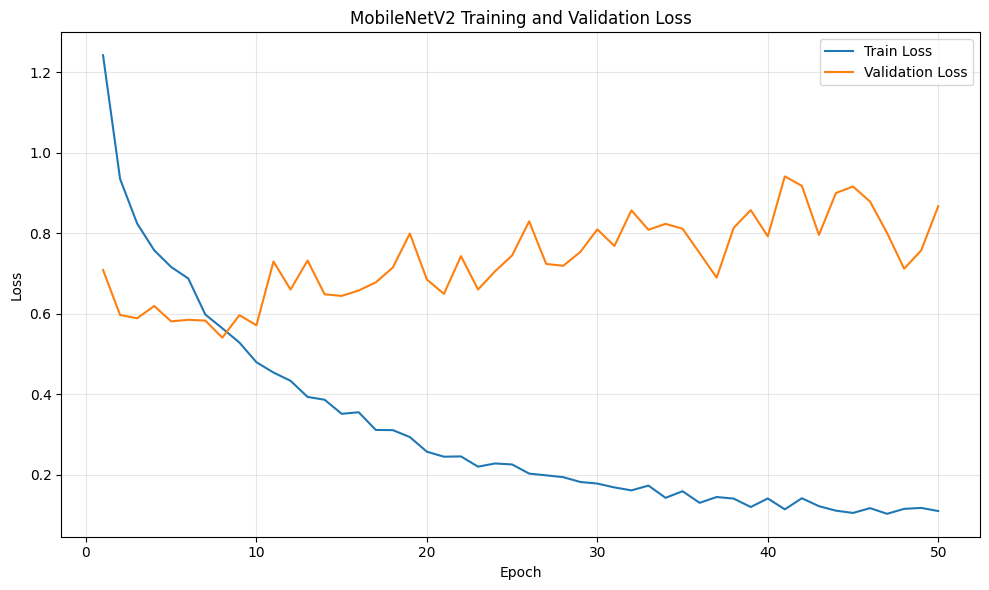

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "loss_curve.png",
    dpi=300
)

plt.show()

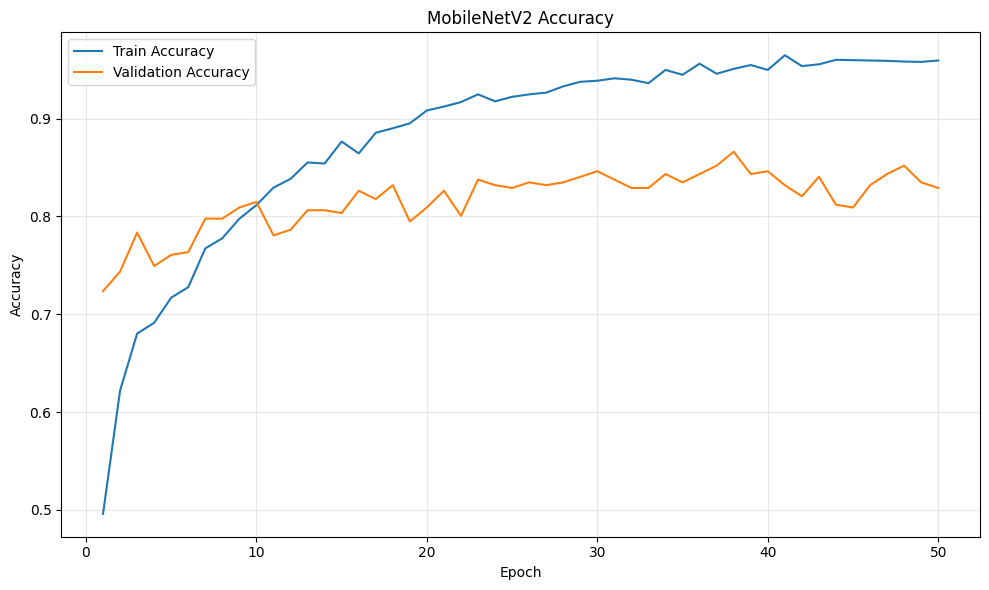

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "accuracy_curve.png",
    dpi=300
)

plt.show()

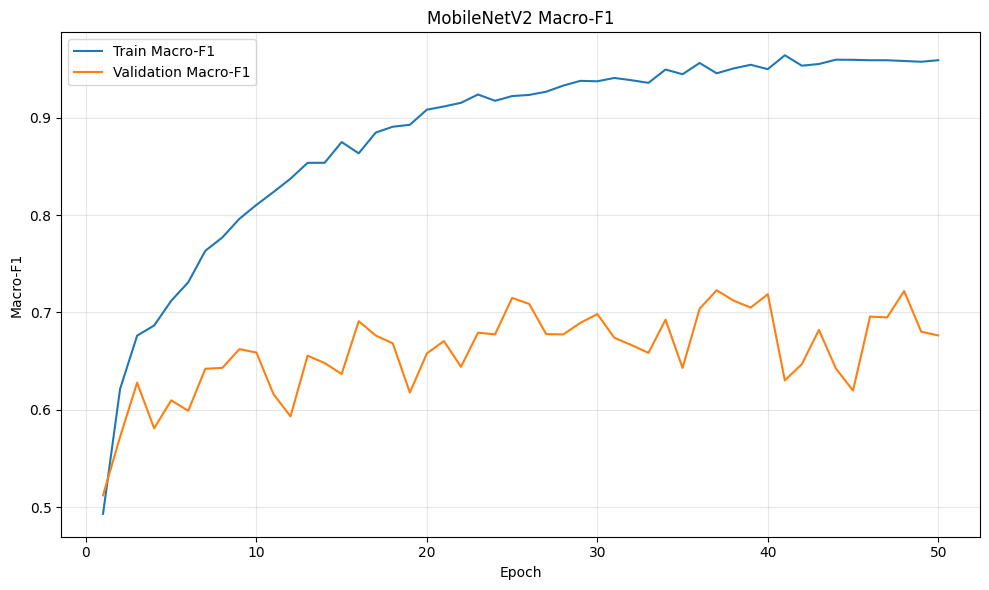

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_f1_macro"],
    label="Train Macro-F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "MobileNetV2 Macro-F1"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "f1_curve.png",
    dpi=300
)

plt.show()

In [22]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded best model from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    checkpoint["val_f1_macro"]
)

Loaded best model from epoch: 37
Best validation Macro-F1: 0.7228255813953488


In [23]:
test_loss, test_metrics, y_true, y_pred, y_prob = run_epoch(
    model,
    test_loader,
    criterion
)

print("=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

print(
    f"Test Loss             : {test_loss:.4f}"
)

print(
    f"Accuracy              : {test_metrics['accuracy']:.4f}"
)

print(
    f"Macro Precision       : {test_metrics['precision_macro']:.4f}"
)

print(
    f"Macro Recall          : {test_metrics['recall_macro']:.4f}"
)

print(
    f"Macro F1              : {test_metrics['f1_macro']:.4f}"
)

print(
    f"Weighted Precision    : {test_metrics['precision_weighted']:.4f}"
)

print(
    f"Weighted Recall       : {test_metrics['recall_weighted']:.4f}"
)

print(
    f"Weighted F1           : {test_metrics['f1_weighted']:.4f}"
)

print(
    f"Balanced Accuracy     : {test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"MCC                   : {test_metrics['mcc']:.4f}"
)

print(
    f"Cohen's Kappa         : {test_metrics['cohen_kappa']:.4f}"
)

print(
    f"ROC-AUC Macro OVR     : {test_metrics['roc_auc_macro_ovr']:.4f}"
)

print(
    f"ROC-AUC Weighted OVR  : {test_metrics['roc_auc_weighted_ovr']:.4f}"
)

FINAL TEST RESULTS
Test Loss             : 0.9358
Accuracy              : 0.8034
Macro Precision       : 0.6617
Macro Recall          : 0.5824
Macro F1              : 0.6045
Weighted Precision    : 0.7966
Weighted Recall       : 0.8034
Weighted F1           : 0.7936
Balanced Accuracy     : 0.5824
MCC                   : 0.6943
Cohen's Kappa         : 0.6918
ROC-AUC Macro OVR     : 0.9032
ROC-AUC Weighted OVR  : 0.9450


In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
No DR,0.978022,0.988889,0.983425,180.000000
Mild,0.500000,0.500000,0.500000,34.000000
Moderate,0.663636,0.793478,0.722772,92.000000
Severe,0.666667,0.333333,0.444444,18.000000
Proliferative DR,0.500000,0.296296,0.372093,27.000000
accuracy,0.803419,0.803419,0.803419,0.803419
macro avg,0.661665,0.582399,0.604547,351.000000
weighted avg,0.796577,0.803419,0.793613,351.000000


In [25]:
report_df.to_csv(
    OUTPUT_DIR /
    "classification_report.csv"
)

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df

,No DR,Mild,Moderate,Severe,Proliferative DR
No DR,178,2,0,0,0
Mild,1,17,16,0,0
Moderate,2,10,73,1,6
Severe,1,1,8,6,2
Proliferative DR,0,4,13,2,8


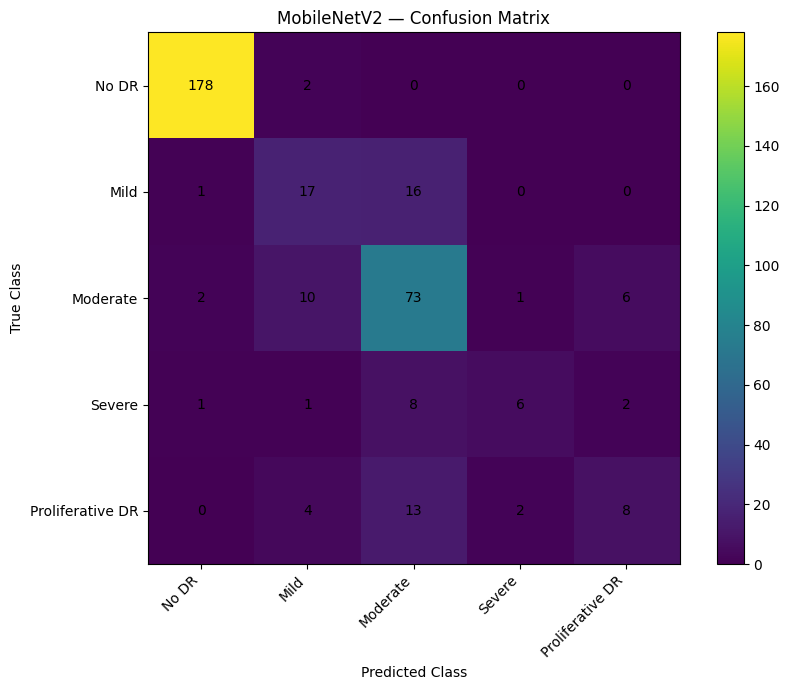

In [27]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title(
    "MobileNetV2 — Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "confusion_matrix.png",
    dpi=300
)

plt.show()

cm_df.to_csv(
    OUTPUT_DIR /
    "confusion_matrix.csv"
)

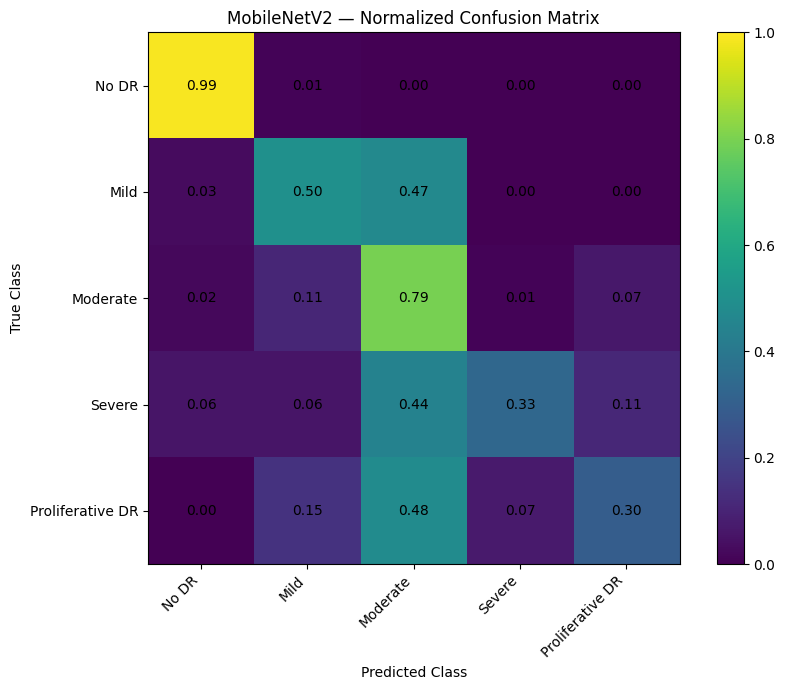

In [28]:
cm_normalized = (
    cm.astype(float) /
    cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(9, 7))

plt.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)

plt.colorbar()

plt.title(
    "MobileNetV2 — Normalized Confusion Matrix"
)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            f"{cm_normalized[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "normalized_confusion_matrix.png",
    dpi=300
)

plt.show()

In [29]:
per_class_results = []

for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )

    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    npv = (
        TN / (TN + FN)
        if (TN + FN) > 0
        else 0
    )

    per_class_results.append({

        "Class": class_name,

        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,

        "Sensitivity_Recall":
            sensitivity,

        "Specificity":
            specificity,

        "PPV_Precision":
            ppv,

        "NPV":
            npv
    })


medical_metrics_df = pd.DataFrame(
    per_class_results
)

medical_metrics_df

,Class,TP,TN,FP,FN,Sensitivity_Recall,Specificity,PPV_Precision,NPV
0,No DR,178,167,4,2,0.988889,0.976608,0.978022,0.988166
1,Mild,17,300,17,17,0.500000,0.946372,0.500000,0.946372
2,Moderate,73,222,37,19,0.793478,0.857143,0.663636,0.921162
3,Severe,6,330,3,12,0.333333,0.990991,0.666667,0.964912
4,Proliferative DR,8,316,8,19,0.296296,0.975309,0.500000,0.943284


In [30]:
medical_metrics_df.to_csv(
    OUTPUT_DIR /
    "per_class_medical_metrics.csv",
    index=False
)

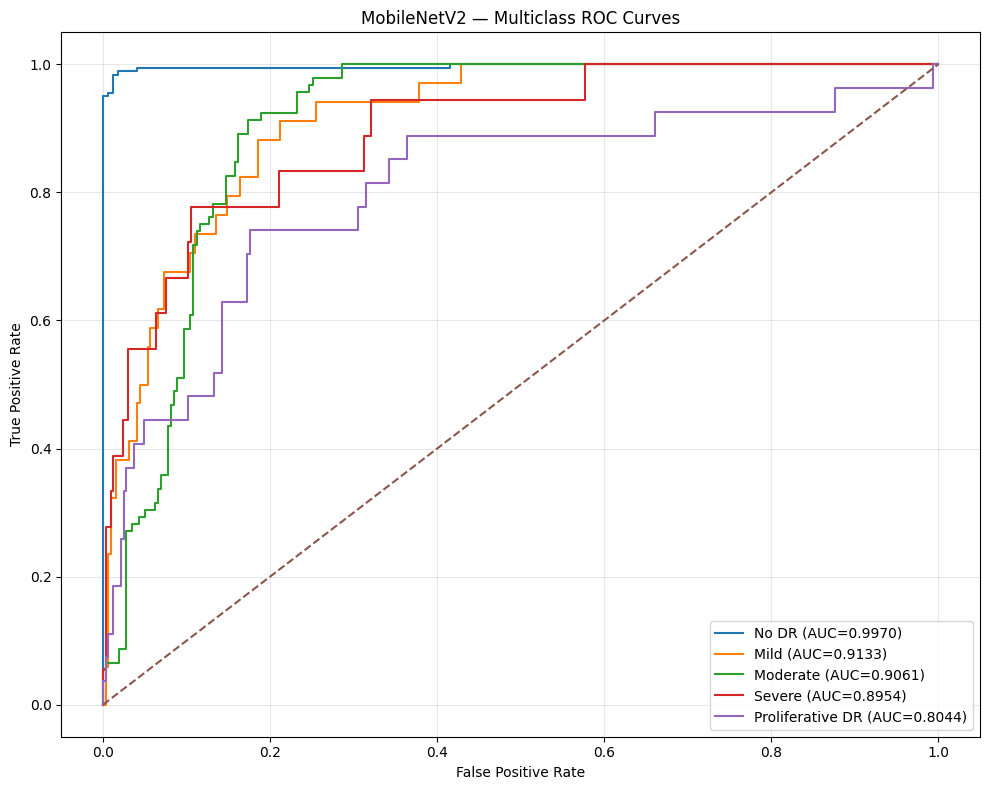

In [31]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(10, 8))

roc_results = []

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, thresholds = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    roc_results.append({
        "class": class_name,
        "auc": roc_auc
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "MobileNetV2 — Multiclass ROC Curves"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "roc_curves.png",
    dpi=300
)

plt.show()

pd.DataFrame(
    roc_results
).to_csv(
    OUTPUT_DIR /
    "roc_auc_per_class.csv",
    index=False
)

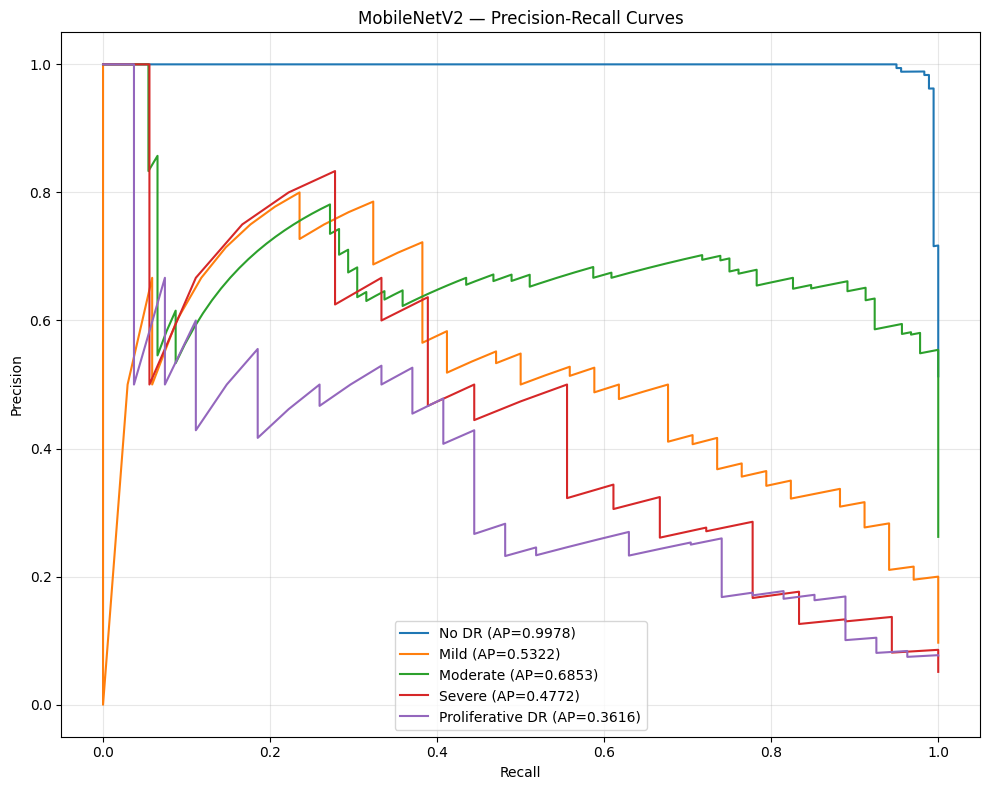

In [32]:
plt.figure(figsize=(10, 8))

pr_results = []

for i, class_name in enumerate(CLASS_NAMES):

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    pr_results.append({
        "class": class_name,
        "average_precision": ap
    })

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP={ap:.4f})"
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "MobileNetV2 — Precision-Recall Curves"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "precision_recall_curves.png",
    dpi=300
)

plt.show()

pd.DataFrame(
    pr_results
).to_csv(
    OUTPUT_DIR /
    "average_precision_per_class.csv",
    index=False
)

In [33]:
roc_df = pd.DataFrame(
    roc_results
)

pr_df = pd.DataFrame(
    pr_results
)

auc_ap_df = roc_df.merge(
    pr_df,
    on="class"
)

auc_ap_df

,class,auc,average_precision
0,No DR,0.997011,0.997781
1,Mild,0.913342,0.532238
2,Moderate,0.906077,0.685284
3,Severe,0.895395,0.477206
4,Proliferative DR,0.804412,0.361614


In [34]:
overall_results = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro Precision",

        "Macro Recall",

        "Macro F1",

        "Weighted Precision",

        "Weighted Recall",

        "Weighted F1",

        "Balanced Accuracy",

        "ROC-AUC Macro OVR",

        "ROC-AUC Weighted OVR",

        "MCC",

        "Cohen's Kappa",

        "Test Loss",

        "Best Epoch",

        "Best Validation Macro F1"
    ],

    "Value": [

        test_metrics["accuracy"],

        test_metrics["precision_macro"],

        test_metrics["recall_macro"],

        test_metrics["f1_macro"],

        test_metrics["precision_weighted"],

        test_metrics["recall_weighted"],

        test_metrics["f1_weighted"],

        test_metrics["balanced_accuracy"],

        test_metrics["roc_auc_macro_ovr"],

        test_metrics["roc_auc_weighted_ovr"],

        test_metrics["mcc"],

        test_metrics["cohen_kappa"],

        test_loss,

        checkpoint["epoch"],

        checkpoint["val_f1_macro"]
    ]
})

overall_results

,Metric,Value
0,Accuracy,0.803419
1,Macro Precision,0.661665
2,Macro Recall,0.582399
3,Macro F1,0.604547
4,Weighted Precision,0.796577
5,Weighted Recall,0.803419
6,Weighted F1,0.793613
7,Balanced Accuracy,0.582399
8,ROC-AUC Macro OVR,0.903248
9,ROC-AUC Weighted OVR,0.945045


In [35]:
overall_results.to_csv(
    OUTPUT_DIR /
    "overall_test_metrics.csv",
    index=False
)

In [36]:
confidence = np.max(
    y_prob,
    axis=1
)

correct = (
    y_pred == y_true
)

print(
    "Mean prediction confidence:",
    confidence.mean()
)

print(
    "Mean confidence - correct:",
    confidence[correct].mean()
)

print(
    "Mean confidence - incorrect:",
    confidence[~correct].mean()
)

Mean prediction confidence: 0.9398464
Mean confidence - correct: 0.9621546
Mean confidence - incorrect: 0.8486735


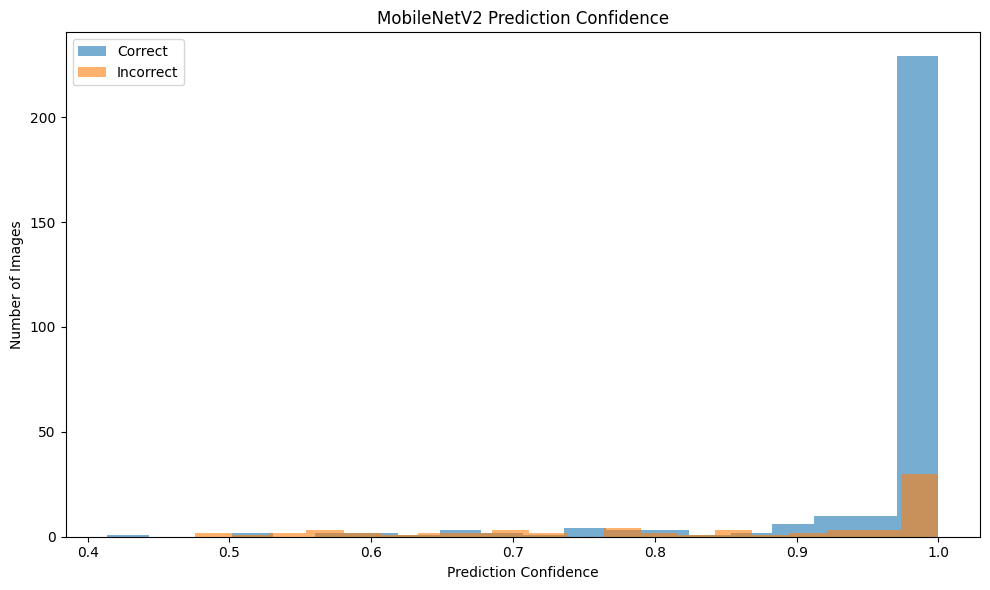

In [37]:
plt.figure(figsize=(10, 6))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")

plt.ylabel("Number of Images")

plt.title(
    "MobileNetV2 Prediction Confidence"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "prediction_confidence.png",
    dpi=300
)

plt.show()

In [38]:
experiment_config = {

    "model": "MobileNetV2",

    "dataset": "APTOS 2019",

    "num_classes": NUM_CLASSES,

    "image_size": IMAGE_SIZE,

    "epochs": EPOCHS,

    "batch_size": BATCH_SIZE,

    "num_workers": NUM_WORKERS,

    "learning_rate": LEARNING_RATE,

    "weight_decay": WEIGHT_DECAY,

    "optimizer": OPTIMIZER_NAME,

    "seed": SEED,

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_macro_f1":
        float(checkpoint["val_f1_macro"])
}

with open(
    OUTPUT_DIR /
    "experiment_config.json",
    "w"
) as f:

    json.dump(
        experiment_config,
        f,
        indent=4
    )

print(
    json.dumps(
        experiment_config,
        indent=4
    )
)

{
    "model": "MobileNetV2",
    "dataset": "APTOS 2019",
    "num_classes": 5,
    "image_size": 224,
    "epochs": 50,
    "batch_size": 16,
    "num_workers": 2,
    "learning_rate": 0.0001,
    "weight_decay": 1e-05,
    "optimizer": "Adam",
    "seed": 42,
    "best_epoch": 37,
    "best_validation_macro_f1": 0.7228255813953488
}


In [39]:
torch.save(
    model.state_dict(),
    OUTPUT_DIR /
    "MobileNetV2_APTOS_best_weights.pth"
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [40]:
print("=" * 80)
print("GENERATED RESULTS")
print("=" * 80)

for file in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        file.name
    )

GENERATED RESULTS
MobileNetV2_APTOS_best_weights.pth
accuracy_curve.png
average_precision_per_class.csv
best_mobilenetv2_aptos.pth
class_distribution.png
classification_report.csv
confusion_matrix.csv
confusion_matrix.png
experiment_config.json
f1_curve.png
loss_curve.png
normalized_confusion_matrix.png
overall_test_metrics.csv
per_class_medical_metrics.csv
precision_recall_curves.png
prediction_confidence.png
roc_auc_per_class.csv
roc_curves.png
training_history.csv
